In [18]:
from matplotlib import pyplot as plt
import numpy as np
import deepRD.tools.trajectoryTools as trajectoryTools


def g_method_xdu(vv_corr, xdu_corr, dt, mass, trunc):
    """Gmethod with external potential."""
    trunc = np.min([len(vv_corr), len(xdu_corr), trunc])
    kernel_i = np.zeros(trunc)
    prefac = 2.0 / (vv_corr[0] * dt)
    for i in range(1, len(kernel_i)):
        # analytically, the difference between mass * vv_corr and xdu_corr is zero,
        # as they are both equal to kbt. Numerically, it helps to keep it in, though.
        kernel_i[i] = mass * (vv_corr[0] - vv_corr[i]) + xdu_corr[i] - xdu_corr[0]
        conv = np.sum(kernel_i[:i] * vv_corr[::-1][len(vv_corr) - i - 1 : -1])
        kernel_i[i] -= dt * conv
        kernel_i[i] *= prefac
    return kernel_i


def g_method_xdu_nomass(vv_corr, xdu_corr, dt, trunc):
    """Compute the integral over the kernel, computes mass via FDT"""
    trunc = np.min([len(vv_corr), len(xdu_corr), trunc])
    kernel_i = np.zeros(trunc)
    prefac = 2.0 / vv_corr[0]
    for i in range(1, trunc):
        kernel_i[i] = prefac * (
            (xdu_corr[i] - vv_corr[i] * xdu_corr[0] / vv_corr[0]) / dt
            - np.sum(kernel_i[1:i] * vv_corr[1:i][::-1])
        )
    return kernel_i


def g_method_vdu(vv_corr, vdu_corr, dt, mass, trunc):
    r"""This is an alternatice volterra method extracting the running integral
    over the memory kernel G(t), where the integral $\int_0^t ds C^{vdU}(s)$ is
    pulled into the convolution integral $\int_0^t ds G(t - s) C^{vv}(s)$ prior
    to approximation with trapezoidal rule.
    Arguments:
        vv_corr (np.ndarray): velocity autocorrelation function
        vdu_corr (np.ndarray): velocity gradient of PMF correlation function
        dt (float): time step
        mass (float): mass
        trunc (int): number of frames of G(t) to compute
        loop (bool): whether to loop to compute covolution integral
    """
    trunc = np.min([len(vv_corr), len(vdu_corr), trunc])
    kernel_int = np.zeros(trunc)
    # to streamline the computation of all terms for the trapezodial rule
    # of the integral over vdu_corr, we precompute the cum sum of vdu_corr
    # where we set the first element to zero
    vdu_corr_cumsum = np.cumsum(np.concatenate([[0.0], vdu_corr[1:trunc]]))
    prefac = 1 / vv_corr[0]
    for i in range(1, len(kernel_int)):
        kernel_int[i] = vdu_corr[0] + vdu_corr[i] + (2 * mass / dt) * (vv_corr[0] - vv_corr[i])
        conv = 0.0
        for j in range(1, i):
            # conv += kernel_int[j] * vv_corr[i - j] + vdu_corr[j]
            conv += kernel_int[j] * vv_corr[i - j]
        kernel_int[i] -= 2 * vdu_corr_cumsum[i - 1]
        kernel_int[i] -= 2 * conv
        kernel_int[i] *= prefac
    return kernel_int


def gamma_method(vv_corr, va_corr, aa_corr, adu_corr, dt, mass, trunc):
    """This is an alternatice volterra method extracting the memory kernel
    $Gamma(t)$ directly. It is based on a volterra method of the second kind.
    Arguments:
        vv_corr (np.ndarray): velocity autocorrelation function
        va_corr (np.ndarray): velocity acceleration correlation function
        aa_corr (np.ndarray): acceleration autocorrelation function (af_corr = mass * caa)
        adu_corr (np.ndarray): acceleration gradient of PMF correlation function
        dt (float): time step
        mass (float): mass
        trunc (int): number of frames of G(t) to compute
        verbose (bool): argument not used, I just added it for consistency with the module to test
    """
    af_corr = mass * aa_corr
    trunc = np.min([len(vv_corr), len(va_corr), len(af_corr), len(adu_corr), trunc])
    kernel = np.zeros(trunc)
    prefac = 1.0 / (vv_corr[0] + va_corr[0] * dt * 0.5)
    kernel[0] = (af_corr[0] + adu_corr[0]) / vv_corr[0]
    for i in range(1, trunc):
        num = af_corr[i] + adu_corr[i]
        # do first instance of loop where j = 0 and we scale
        # with 0.5 due to trapezoidal rule
        num -= 0.5 * dt * va_corr[i] * kernel[0]
        for j in range(1, i):
            num -= dt * va_corr[i - j] * kernel[j]
        kernel[i] = num
        kernel[i] = prefac * num
    return kernel



def correlation_fft(a, b, trunc):
    """Calculates correlation via FFT."""
    len_a = len(a)
    a = np.concatenate([a, np.zeros(len_a)])
    b = np.concatenate([b, np.zeros(len_a)])
    a_fft = np.fft.fft(a)
    b_fft = np.fft.fft(b)
    corr = np.fft.ifft(a_fft * np.conj(b_fft))
    corr = corr[:trunc].real
    corr /= np.linspace(len_a, len_a - trunc + 1, trunc)
    return corr


def main():

    systemType='dimer'
    # Datasets directory
    localDirectory = f"/group/ag_cmb/scratch/maojrs/stochasticClosure/{systemType}/boxsize5/benchmark/"

    #  Loading trajectories.
    n_trajs = 1
    fnums = np.random.choice(2500, n_trajs, replace=False)
    dataset=None

    for f_num in fnums:
        try:
            ds = trajectoryTools.loadTrajectory(localDirectory + "simMoriZwanzig_", f_num)[np.newaxis, :]
        except FileNotFoundError:
            print(f'File {f_num} not available.')
            continue
              
        if dataset is None:
            dataset = ds
        else:
            dataset = np.concatenate((dataset, ds), axis=0)
        
    print('Trajectories loaded.')

    q_1 = dataset[:, ::2, 1:4]
    q_2 = dataset[:, 1::2, 1:4]

    # relative position, velocity
    q = q_1 - q_2

    # 1D relative distance and relative velocity
    dt = 0.05
    data = np.linalg.norm(q, axis=2)
    trunc = 10 # how many samples to compute for the kernel

    particleDiameter = 0.5
    x0 = 1.0*particleDiameter # location of first minima
    rad = 1.0*particleDiameter
    arg = (data - rad - x0)/rad
    du = (-8)*(1-arg**2)*arg/rad
    
    # compute the gradient of the (mean) force at each frame of the trajectory
    # for example, for a harmonic potential, du would be du = k * data
    # for a arbitrary free energy we would use du = np.interp(data, bins_fe, np.gradient(fe, bins_fe))
    # and we could compute fe from histogram of the data via:
    # hist, bins_fe = np.histogram(data, bins=150)
    # bins_fe = 0.5 * (bins_fe[1:] + bins_fe[:-1])
    # fe = -kbt * np.log(hist)
    
    vv_corr = np.zeros(trunc)
    xdu_corr = np.zeros(trunc)
    
    for i, traj in enumerate(data):
        velocity = np.gradient(traj, dt) # could also use np.diff(data) / dt for some of the correlations
        vv_corr += correlation_fft(velocity, velocity, trunc)
        xdu_corr += correlation_fft(velocity, du[i], trunc)
        
    vv_corr /= data.shape[0]
    xdu_corr /= data.shape[0]

    kernel_integral = g_method_xdu_nomass(vv_corr, xdu_corr, dt, trunc)
    kernel = np.gradient(kernel_integral, dt)

    # plot
    time = np.arange(trunc) * dt
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].plot(time, kernel)
    axes[0].set(xlabel="t", ylabel=r"$\Gamma(t)")
    axes[1].plot(time, kernel_integral)
    axes[1].set(xlabel="t", ylabel=r"$G(t) := int_0^t ds \Gamma(s)")
    plt.show()


Trajectories loaded.


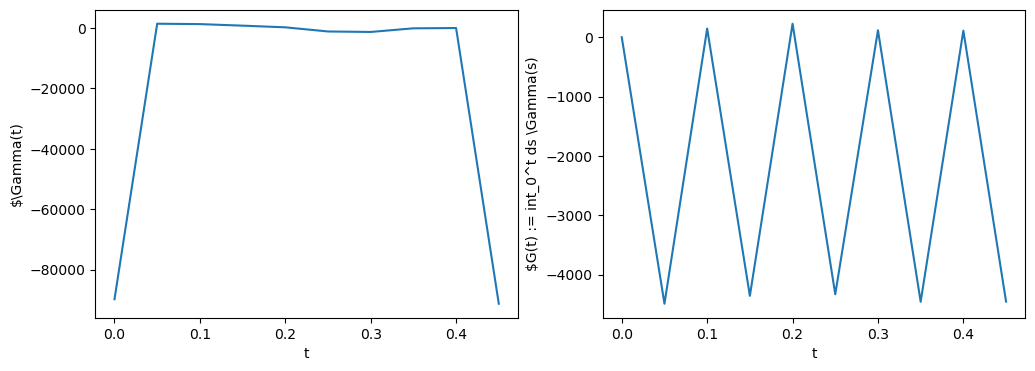

In [19]:
main()